# Lid-Driven Cavity — PINN Solver
# Physics-Informed Neural Network for 2-D incompressible Navier-Stokes 

In [63]:
import os
import torch
import copy
import time
import numpy as np
import matplotlib.pyplot as plt

import importlib
import pinn
importlib.reload(pinn)

from pinn import PINN, ns_residual, make_boundary_data, make_collocation_points
from pinn import eval_all_losses, eval_flow_field, visualize, plot_flow_field, make_animation


## Hyperparameters and Data

In [15]:
# Define Hyperparameters
N_b = 1_000  # boundary sample points
N_f = 10_000  # training collocation points
N_eval_pde = 2_000  # fresh points for eval L_pde (every 100 epochs)
nu = 0.01  # kinematic viscosity  →  Re = U*L/nu = 1000
layers = [2, 64, 64, 64, 64, 3]

lr = 1e-3
num_epochs = 200_000
log_every = 100

Re = round(1 / nu)
print(f"Re              : {Re}")

img_dir = f"images/Re={Re}"
os.makedirs(img_dir, exist_ok=True)

print(f"Boundary points : {N_b}  (resampled each epoch)")
print(f"Collocation pts : {N_f}  (resampled each epoch)")
print(f"Image dir       : {img_dir}")

# Ghia et al. (1982) benchmark — u at (x=0.5, y=0.9609) for each Re
ghia_u = {100: 0.73722, 400: 0.61756, 1000: 0.51117, 3200: 0.46547,
           5000: 0.45992, 7500: 0.47323, 10000: 0.48070}
ghia_ref = ghia_u.get(Re, float('nan'))
print(f"Ghia ref u(0.5, 0.9609) : {ghia_ref}")

Re              : 100
Boundary points : 1000  (resampled each epoch)
Collocation pts : 10000  (resampled each epoch)
Image dir       : images/Re=100
Ghia ref u(0.5, 0.9609) : 0.73722


## Initialize Model 

In [ ]:
net = PINN(layers)
opt = torch.optim.Adam(net.parameters(), lr=lr)

epochs_train   = []
train_loss     = []
train_pde_loss = []
train_bc_loss  = []
train_p_loss   = []

epochs_eval   = []
eval_pde_loss = []
eval_bc_loss  = []
eval_p_loss   = []

snapshots = []  # list of (epoch, state_dict) for animation
epoch = 0

total_params = sum(p.numel() for p in net.parameters())
print(f"Architecture : {layers}")
print(f"Parameters   : {total_params:,}")

Architecture : [2, 64, 64, 64, 64, 3]
Parameters   : 12,867


In [59]:
def save_frame(net, epoch):
    l_pde, l_bc, l_p = eval_all_losses(net, nu, N_eval=N_eval_pde)
    epochs_eval.append(epoch)
    eval_pde_loss.append(l_pde)
    eval_bc_loss.append(l_bc)
    eval_p_loss.append(l_p)

    fig, _ = plot_flow_field(net, epoch, nu)
    fig.savefig(f"{img_dir}/Re={Re}, epoch={epoch:06d}.png", dpi=80, bbox_inches='tight')
    plt.close(fig)


def log_and_visualize(net, epoch, snapshots, loss_bc, loss_pde, loss_p):
    snapshots.append((epoch, copy.deepcopy(net.state_dict())))
    visualize(net, epoch, {
        'epochs_train':   epochs_train,
        'train_pde_loss': train_pde_loss,
        'train_bc_loss':  train_bc_loss,
        'train_p_loss':   train_p_loss,
        'epochs_eval':    epochs_eval,
        'eval_pde_loss':  eval_pde_loss,
        'eval_bc_loss':   eval_bc_loss,
        'eval_p_loss':    eval_p_loss,
    }, nu=nu)

    if epoch % log_every == 0:
        print(f"\nepoch {epoch:>6d} | L_bc {loss_bc.item():.3e} | L_pde {loss_pde.item():.3e} | "
              f"L_p {loss_p.item():.3e} | eval L_pde {eval_pde_loss[-1]:.3e}")
        with torch.no_grad():
            u_pred, v_pred, p_pred = net(torch.tensor([[0.5]]), torch.tensor([[0.9609]]))
            t_w = torch.linspace(0, 1, 1_000).unsqueeze(1)
            z_w, o_w = torch.zeros_like(t_w), torch.ones_like(t_w)
            u_b, v_b, _ = net(t_w, z_w)
            u_l, v_l, _ = net(z_w, t_w)
            u_r, v_r, _ = net(o_w, t_w)
        print(f"  u(0.5, 0.9609) = {u_pred.item():.4f}   (expect {ghia_ref:.5f} — Ghia et al. Re={Re})")
        print(f"  v(0.5, 0.9609) = {v_pred.item():.4f}")
        print(f"  p(0.5, 0.9609) = {p_pred.item():.4f}")
        for name, u, v in [('bottom (y=0)', u_b, v_b), ('left   (x=0)', u_l, v_l), ('right  (x=1)', u_r, v_r)]:
            print(f"  {name} : u mean={u.mean():.4f}  std={u.std():.4f}   "
                  f"v mean={v.mean():.4f}  std={v.std():.4f}   (expect 0, 0)")


## Training

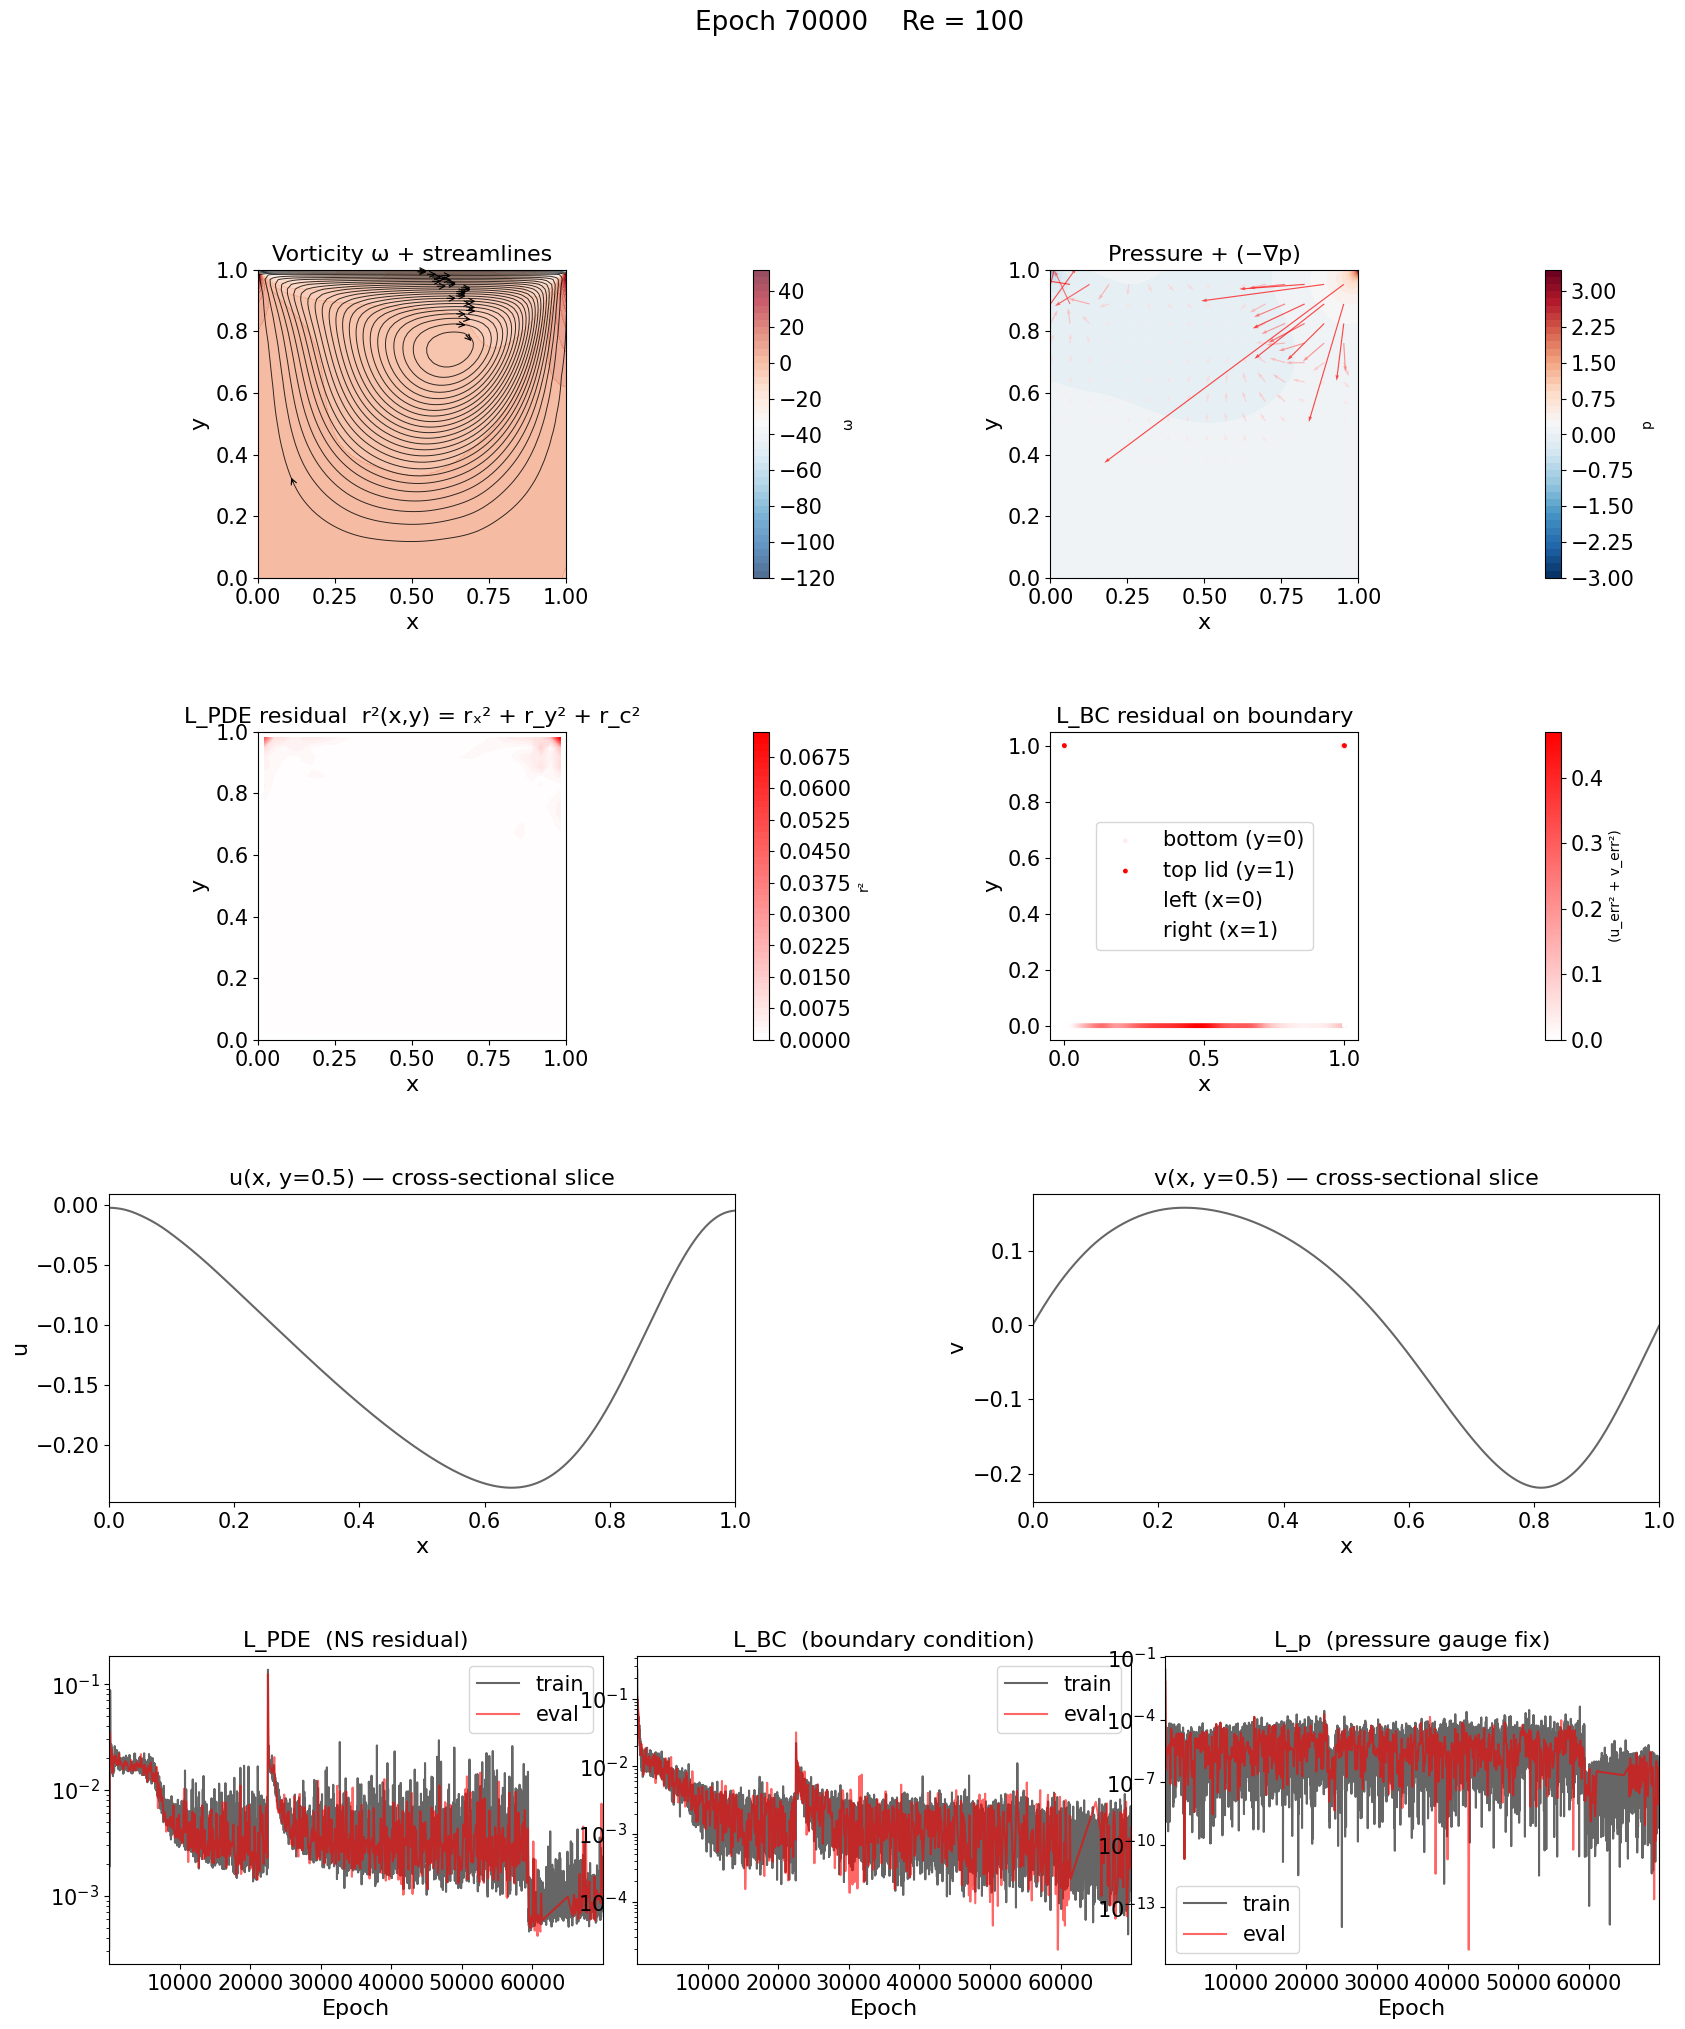


epoch  70000 | L_bc 5.517e-04 | L_pde 7.709e-04 | L_p 9.472e-08 | eval L_pde 5.549e-04
  u(0.5, 0.9609) = 0.7272   (expect 0.73722 — Ghia et al. Re=100)
  v(0.5, 0.9609) = 0.0129
  p(0.5, 0.9609) = -0.0308
  bottom (y=0) : u mean=-0.0044  std=0.0021   v mean=0.0012  std=0.0014   (expect 0, 0)
  left   (x=0) : u mean=-0.0009  std=0.0306   v mean=-0.0001  std=0.0099   (expect 0, 0)
  right  (x=1) : u mean=-0.0019  std=0.0360   v mean=0.0010  std=0.0100   (expect 0, 0)
....

In [ ]:
t_train_start = time.perf_counter()

while epoch < num_epochs:
    epoch += 1
    t_step_start = time.perf_counter()

    opt.zero_grad()

    x_bc, y_bc, u_bc, v_bc = make_boundary_data(N_b)
    x_f, y_f = make_collocation_points(N_f)

    u_p, v_p, _ = net(x_bc, y_bc)
    loss_bc = ((u_p - u_bc)**2 + (v_p - v_bc)**2).mean()

    r_x, r_y, r_c = ns_residual(net, x_f, y_f, nu)
    loss_pde = (r_x**2 + r_y**2 + r_c**2).mean()

    _, _, p_mid = net(torch.tensor([[0.5]]), torch.tensor([[0.5]]))
    loss_p = p_mid**2

    loss = 10 * loss_bc + loss_pde + 10 * loss_p
    loss.backward()
    opt.step()

    epochs_train.append(epoch)
    train_loss.append(loss.item())
    train_pde_loss.append(loss_pde.item())
    train_bc_loss.append(loss_bc.item())
    train_p_loss.append(loss_p.item())

    if epoch % 10 == 0:
        save_frame(net, epoch)

    if epoch % 1000 == 0:
        total_min = (time.perf_counter() - t_train_start) / 60
        print(f"{total_min:.1f} min  (epoch:{epoch})\n", flush=True)
        log_and_visualize(net, epoch, snapshots, loss_bc, loss_pde, loss_p)
    elif epoch % 100 == 0:
        print(epoch, end=' ', flush=True)
    elif epoch % 10 == 0:
        print('.', end='', flush=True)

print()
total_min = (time.perf_counter() - t_train_start) / 60
print(f"Training complete — {total_min:.1f} min  (epoch:{epoch})")


## Inference

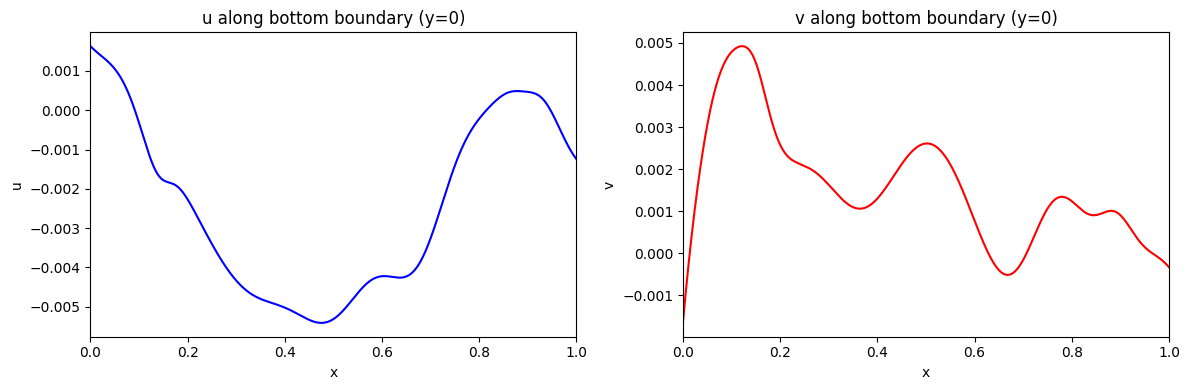

mu (u_pred): -0.0024
sigma  (u_pred): 0.0022
mu (v_pred): 0.0016
sigma (v_pred): 0.0014


In [61]:
x_q = torch.linspace(0, 1, 1000).unsqueeze(1)
y_q = torch.zeros((1000, 1))

with torch.no_grad():
    u_pred, v_pred, p_pred = net(x_q, y_q)
    import matplotlib.pyplot as plt

    x_plot = x_q.squeeze().numpy()
    u_plot = u_pred.squeeze().numpy()
    v_plot = v_pred.squeeze().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(x_plot, u_plot, c='b')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('u')
    axes[0].set_title('u along bottom boundary (y=0)')
    axes[0].margins(x=0)

    axes[1].plot(x_plot, v_plot, c='r')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('v')
    axes[1].set_title('v along bottom boundary (y=0)')
    axes[1].margins(x=0)

    plt.tight_layout()
    plt.show()

print(f"mu (u_pred): {u_pred.mean().item():.4f}")
print(f"sigma  (u_pred): {u_pred.std().item():.4f}")
print(f"mu (v_pred): {v_pred.mean().item():.4f}")
print(f"sigma (v_pred): {v_pred.std().item():.4f}")

In [47]:
x_q = torch.tensor([[0.5]])
y_q = torch.tensor([[0.9609]])

with torch.no_grad():
    u_pred, v_pred, p_pred = net(x_q, y_q)

print(f"u = {u_pred.item():.4f}   (expect {ghia_ref:.5f} — Ghia et al. Re={Re}, y=0.9609)")
print(f"v = {v_pred.item():.4f}")
print(f"p = {p_pred.item():.4f}")

u = 0.7466   (expect 0.73722 — Ghia et al. Re=100, y=0.9609)
v = 0.0120
p = -0.0372


In [48]:
N_wall = 1_000
t = torch.linspace(0, 1, N_wall).unsqueeze(1)
z = torch.zeros_like(t)
o = torch.ones_like(t)

with torch.no_grad():
    u_b, v_b, _ = net(t, z)  # bottom y=0
    u_l, v_l, _ = net(z, t)  # left   x=0
    u_r, v_r, _ = net(o, t)  # right  x=1

for name, u, v in [('bottom (y=0)', u_b, v_b), ('left   (x=0)', u_l, v_l), ('right  (x=1)', u_r, v_r)]:
    print(f"{name} : u mean={u.mean():.4f}  std={u.std():.4f}   "
          f"v mean={v.mean():.4f}  std={v.std():.4f}   (expect 0, 0)")


bottom (y=0) : u mean=0.0125  std=0.0021   v mean=0.0038  std=0.0013   (expect 0, 0)
left   (x=0) : u mean=0.0165  std=0.0186   v mean=0.0162  std=0.0276   (expect 0, 0)
right  (x=1) : u mean=0.0139  std=0.0295   v mean=0.0049  std=0.0083   (expect 0, 0)


### Horizontal cross-section at y = 0.5

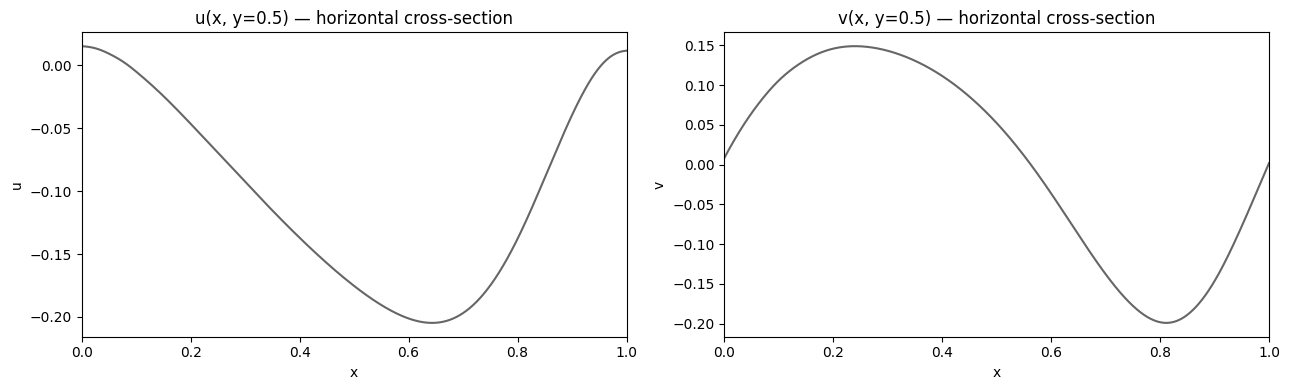

In [49]:
N_section = 10_000
x_section = torch.linspace(0, 1, N_section).unsqueeze(1)
y_section  = torch.full((N_section, 1), 0.5)

with torch.no_grad():
    u_section, v_section, _ = net(x_section, y_section)

u_section = u_section.squeeze().numpy()
v_section = v_section.squeeze().numpy()
x_plot    = x_section.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(x_plot, u_section, c='k', alpha=0.6)
axes[0].set_xlabel("x")
axes[0].set_ylabel("u")
axes[0].set_title("u(x, y=0.5) — horizontal cross-section")
axes[0].margins(x=0)

axes[1].plot(x_plot, v_section, c='k', alpha=0.6)
axes[1].set_xlabel("x")
axes[1].set_ylabel("v")
axes[1].set_title("v(x, y=0.5) — horizontal cross-section")
axes[1].margins(x=0)

plt.tight_layout()
plt.show()

## Visualization

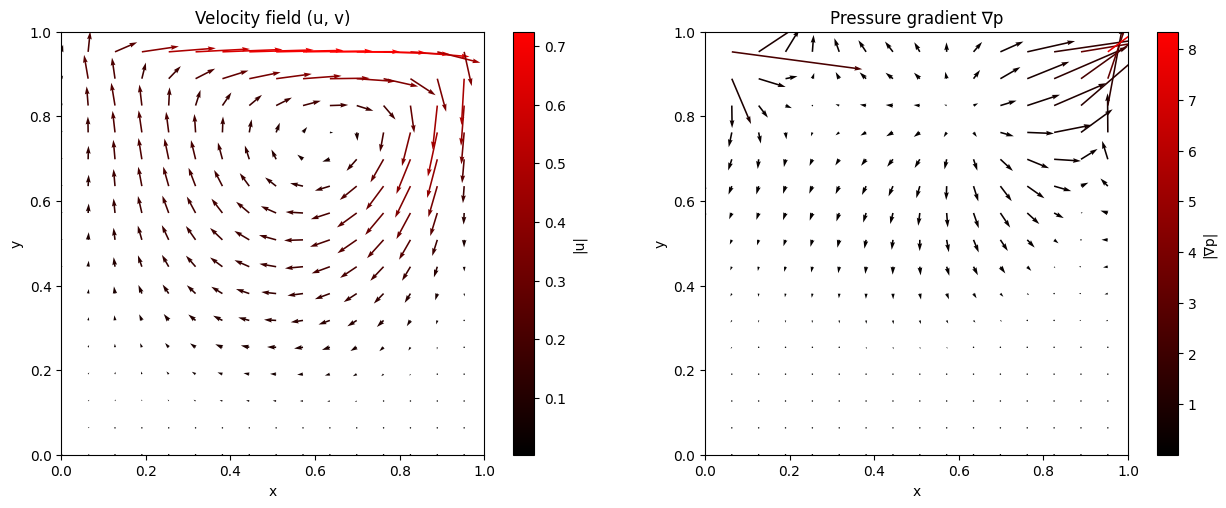

In [50]:
from matplotlib.colors import LinearSegmentedColormap

black_red = LinearSegmentedColormap.from_list("black_red", ["black", "red"])

step = 4  # quiver subsampling → 16×16 arrows on 64×64 grid
xs, ys, U, V, P = eval_flow_field(net, N=64)

dP_dx, dP_dy = np.gradient(P, xs, ys)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("white")

# Left: velocity quiver coloured by speed
speed = np.sqrt(U**2 + V**2)
q0 = axes[0].quiver(
    xs[::step], ys[::step],
    U[::step, ::step].T,
    V[::step, ::step].T,
    speed[::step, ::step].T.flatten(),
    cmap=black_red,
)
plt.colorbar(q0, ax=axes[0], label="|u|")
axes[0].set_title("Velocity field (u, v)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_aspect("equal")

# Right: grad(p) quiver coloured by magnitude
mag = np.sqrt(dP_dx**2 + dP_dy**2)
q1 = axes[1].quiver(
    xs[::step], ys[::step],
    dP_dx[::step, ::step].T,
    dP_dy[::step, ::step].T,
    mag[::step, ::step].T.flatten(),
    cmap=black_red,
)
plt.colorbar(q1, ax=axes[1], label="|∇p|")
axes[1].set_title("Pressure gradient ∇p")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

In [51]:
# Create animation from saved frames
import glob
import subprocess

every_n = 10   # use every 10th file  →  ~2000 frames
fps     = 20   # playback speed

frames = sorted(glob.glob(f"{img_dir}/*.png"))[::every_n]
list_path = f"{img_dir}/frames.txt"
with open(list_path, "w") as f:
    for path in frames:
        f.write(f"file '{os.path.abspath(path)}'\n"
                f"duration {1/fps}\n")

out_path = f"images/Re={Re}.mp4"
subprocess.run([
    "ffmpeg", "-y",
    "-f", "concat", "-safe", "0", "-i", list_path,
    "-vf", "scale=trunc(iw/2)*2:trunc(ih/2)*2",
    "-c:v", "libx264", "-pix_fmt", "yuv420p",
    out_path,
], check=True)

os.remove(list_path)
print(f"Saved {len(frames)} frames → {out_path}")

ffmpeg version 7.0.2 Copyright (c) 2000-2024 the FFmpeg developers
  built with Apple clang version 15.0.0 (clang-1500.3.9.4)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.0.2 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex --

Saved 547 frames → images/Re=100.mp4


[vf#0:0 @ 0x15a608a60] Reconfiguring filter graph because video parameters changed to rgba(pc, gbr), 1365x409
[vf#0:0 @ 0x15a608a60] Reconfiguring filter graph because video parameters changed to rgba(pc, gbr), 1369x409
[vf#0:0 @ 0x15a608a60] Reconfiguring filter graph because video parameters changed to rgba(pc, gbr), 1365x409
[vf#0:0 @ 0x15a608a60] Reconfiguring filter graph because video parameters changed to rgba(pc, gbr), 1369x409
[out#0/mp4 @ 0x15a6073d0] video:5558KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.158636%
frame=  684 fps=223 q=-1.0 Lsize=    5567KiB time=00:00:27.28 bitrate=1671.8kbits/s dup=137 drop=0 speed=8.91x    
[libx264 @ 0x15a608230] frame I:3     Avg QP:21.76  size: 48391
[libx264 @ 0x15a608230] frame P:192   Avg QP:24.74  size: 15075
[libx264 @ 0x15a608230] frame B:489   Avg QP:27.40  size:  5422
[libx264 @ 0x15a608230] consecutive B-frames:  0.7%  9.4%  7.5% 82.5%
[libx264 @ 0x15a608230] mb I  I16..4: 19.3% 25.7% 55